# Predictive model performance




## 0.Package loading and installation


In [ ]:
# For Jupyter/Colab notebooks
%reset -f
import gc
gc.collect()

import numpy as np
import pandas as pd
from rpy2.robjects import r, pandas2ri

!pip install scikit-survival # Install scikit-survival if not already installed
!pip install miceforest --no-cache-dir
!pip install numpy cryptography

from sksurv.metrics import (
    concordance_index_ipcw,
    brier_score,
    integrated_brier_score
)
from sksurv.util import Surv

pandas2ri.activate()

#Glimpse function
def glimpse(df, max_width=80):
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
    for col in df.columns:
        dtype = df[col].dtype
        preview = df[col].astype(str).head(5).tolist()
        preview_str = ", ".join(preview)
        if len(preview_str) > max_width:
            preview_str = preview_str[:max_width] + "..."
        print(f"{col:<30} {str(dtype):<15} {preview_str}")



In [ ]:
from google.colab import userdata

# Names of the objects (and secrets)
object_names = [f"imputation_{d}" for d in range(1, 6)]   # 1–5

for name in object_names:
    file_id = userdata.get(name)   # secret stored with this key
    if file_id is None:
        raise ValueError(f"No file_id found in userdata for key '{name}'")

    output_file = f"{name}.parquet"
    print(f"Downloading {name} -> {output_file}")
    !gdown --id {file_id} --output {output_file} --quiet

# Retrieve the file ID securely (do not print it)
file_id = userdata.get('id_centro')

# Download the file quietly
!gdown --id {file_id} --output id_centro.Rds --quiet



/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in versio

 ## 1.Load database

In [1]:
import os

# List files in the /content/ directory to verify .Rds files are present
print(os.listdir('/'))

['bin', 'boot', 'dev', 'etc', 'home', 'lib', 'lib32', 'lib64', 'libx32', 'media', 'mnt', 'opt', 'proc', 'root', 'run', 'sbin', 'srv', 'sys', 'tmp', 'usr', 'var', 'kaggle', 'datalab', 'tools', 'content', 'python-apt', 'python-apt.tar.xz', 'NGC-DL-CONTAINER-LICENSE', 'cuda-keyring_1.1-1_all.deb']


Import parquets of the imputations.

In [2]:

import pandas as pd

for i in range(1, 6):
    globals()[f"imputation_{i}"] = pd.read_parquet(f"/content/imputation_{i}.parquet")

# Now df1, df2, ..., df5 exist as separate variables
print(imputation_1.head())



FileNotFoundError: [Errno 2] No such file or directory: '/content/imputation_1.parquet'

Glimpse

In [ ]:
glimpse(imputation_1)

Rows: 88504 | Columns: 78
readmit_time_from_adm_m        float64         84.93548387096774, 12.833333333333334, 13.733333333333333, 11.966666666666667, 1...
death_time_from_adm_m          float64         84.93548387096774, 87.16129032258064, 117.2258064516129, 98.93548387096774, 37.9...
adm_age_rec3                   float64         31.53, 20.61, 42.52, 60.61, 45.08
porc_pobr                      float64         0.175679117441177, 0.187835901975632, 0.130412444472313, 0.133759185671806, 0.08...
dit_m                          float64         15.967741935483872, 5.833333333333334, 0.4752688172043005, 6.966666666666667, 6....
national_foreign               int32           0, 0, 0, 0, 0
ethnicity                      float64         0.0, 0.0, 0.0, 0.0, 0.0
dg_psiq_cie_10_instudy         bool            False, False, True, False, False
dg_psiq_cie_10_dg              bool            True, False, False, True, False
dx_f3_mood                     int32           0, 0, 0, 0, 0
dx_f6_personality

### 1.2. Build Surv objects from df_final

In [ ]:

from sksurv.util import Surv

for i in range(1, 6):
    # Get the DataFrame
    df = globals()[f"imputation_{i}"]

    # Extract time and event arrays
    time_readm  = df["readmit_time_from_disch_m"].to_numpy()
    event_readm = (df["readmit_event"].to_numpy() == 1)
    time_death  = df["death_time_from_disch_m"].to_numpy()
    event_death = (df["death_event"].to_numpy() == 1)

    # Create survival objects
    y_surv_readm = Surv.from_arrays(event=event_readm, time=time_readm)
    y_surv_death = Surv.from_arrays(event=event_death, time=time_death)

    # Store in global variables (optional but matches your pattern)
    globals()[f"y_surv_readm_{i}"]  = y_surv_readm
    globals()[f"y_surv_death_{i}"]  = y_surv_death

    # Print info
    print(f"\n--- Imputation {i} ---")
    print("y_surv_readm dtype:", y_surv_readm.dtype, "shape:", y_surv_readm.shape)
    print("y_surv_death dtype:", y_surv_death.dtype, "shape:", y_surv_death.shape)



--- Imputation 1 ---
y_surv_readm dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)
y_surv_death dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)

--- Imputation 2 ---
y_surv_readm dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)
y_surv_death dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)

--- Imputation 3 ---
y_surv_readm dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)
y_surv_death dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)

--- Imputation 4 ---
y_surv_readm dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)
y_surv_death dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)

--- Imputation 5 ---
y_surv_readm dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)
y_surv_death dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)


## 2.Fit Cox PH models in Python (readmission & death)

For each imputed dataset (1–5), we identified and removed predictors with zero variance, as they provide no useful information and can destabilize models. We printed the dropped variables and produced a cleaned version of each design matrix. This ensures that all downstream analyses use only informative predictors.

In [ ]:
# 1. Define columns to exclude (same as before)
target_cols = [
    "readmit_time_from_disch_m",
    "readmit_event",
    "death_time_from_disch_m",
    "death_event",
]

leak_time_cols = [
    "readmit_time_from_adm_m",
    "death_time_from_adm_m",
]

cols_to_exclude = target_cols + leak_time_cols

# 2. Create list of your EXISTING imputation DataFrames (1-5)
imputed_dfs = [
    imputation_1,
    imputation_2,
    imputation_3,
    imputation_4,
    imputation_5
]

# 3. Preprocessing loop
X_reduced_list = []

for d, df in enumerate(imputed_dfs):
    imputation_num = d + 1  # Convert 0-index to 1-index for display

    print(f"\n=== Imputation dataset {imputation_num} ===")

    # a) Identify and drop constant predictors
    const_mask = (df.nunique(dropna=False) <= 1)
    dropped_const = df.columns[const_mask].tolist()
    print(f"Constant predictors dropped ({len(dropped_const)}):")
    print(dropped_const if dropped_const else "None")

    # b) Remove constant columns
    X_reduced = df.loc[:, ~const_mask]

    # c) Drop target/leakage columns (if present)
    cols_to_drop = [col for col in cols_to_exclude if col in X_reduced.columns]
    if cols_to_drop:
        X_reduced = X_reduced.drop(columns=cols_to_drop)
        print(f"Dropped target/leakage columns: {cols_to_drop}")
    else:
        print("No target/leakage columns found to drop")

    # d) Store cleaned DataFrame
    X_reduced_list.append(X_reduced)

    # e) Report shapes
    print(f"Original shape: {df.shape}")
    print(f"Cleaned shape: {X_reduced.shape} (removed {df.shape[1] - X_reduced.shape[1]} columns)")

print("\n✅ Preprocessing complete! X_reduced_list contains 5 cleaned DataFrames.")


=== Imputation dataset 1 ===
Constant predictors dropped (0):
None
Dropped target/leakage columns: ['readmit_time_from_disch_m', 'readmit_event', 'death_time_from_disch_m', 'death_event', 'readmit_time_from_adm_m', 'death_time_from_adm_m']
Original shape: (88504, 78)
Cleaned shape: (88504, 72) (removed 6 columns)

=== Imputation dataset 2 ===
Constant predictors dropped (0):
None
Dropped target/leakage columns: ['readmit_time_from_disch_m', 'readmit_event', 'death_time_from_disch_m', 'death_event', 'readmit_time_from_adm_m', 'death_time_from_adm_m']
Original shape: (88504, 78)
Cleaned shape: (88504, 72) (removed 6 columns)

=== Imputation dataset 3 ===
Constant predictors dropped (0):
None
Dropped target/leakage columns: ['readmit_time_from_disch_m', 'readmit_event', 'death_time_from_disch_m', 'death_event', 'readmit_time_from_adm_m', 'death_time_from_adm_m']
Original shape: (88504, 78)
Cleaned shape: (88504, 72) (removed 6 columns)

=== Imputation dataset 4 ===
Constant predictors dr

For each imputed dataset, we fitted two regularized Cox models (one for readmission and one for death) using Coxnet, which applies elastic-net penalization with a strong LASSO component to enable variable selection. The loop fits both models on every imputation, prints basic model information, and stores all fitted models so they can later be combined or compared across imputations.

In [ ]:
from sksurv.linear_model import CoxnetSurvivalAnalysis

# Initialize lists to store models for each imputation
coxnet_readm_list = []  # Will hold 5 models for readmission
coxnet_death_list = []  # Will hold 5 models for death

# Loop over each imputed dataset (0-indexed in list, but corresponds to imputation 1-5)
for d, X_imp in enumerate(X_reduced_list):
    imputation_num = d + 1  # Convert to 1-indexed for readability

    print(f"\n{'='*50}")
    print(f"Fitting CoxNet models on Imputation Dataset {imputation_num}")
    print(f"{'='*50}")

    # --- Get the CORRECT survival arrays for this imputation ---
    y_readm = globals()[f"y_surv_readm_{imputation_num}"]
    y_death = globals()[f"y_surv_death_{imputation_num}"]

    print(f"X_imp shape: {X_imp.shape}")
    print(f"y_readm shape: {y_readm.shape}, dtype: {y_readm.dtype}")
    print(f"y_death shape: {y_death.shape}, dtype: {y_death.dtype}")

    # --- Readmission CoxNet ---
    print("\n[Readmission Model]")
    coxnet_readm = CoxnetSurvivalAnalysis(
        l1_ratio=0.9,
        alpha_min_ratio=0.01,
        n_alphas=50,
        normalize=True,
        fit_baseline_model=True,
        max_iter=100000,
        verbose=False
    )
    coxnet_readm.fit(X_imp, y_readm)
    coxnet_readm_list.append(coxnet_readm)

    print(f"✓ Readmission CoxNet fitted for Imputation {imputation_num}")
    print(f"  Features used: {coxnet_readm.n_features_in_}")
    print(f"  Alpha path: {len(coxnet_readm.alphas_)} values")

    # --- Death CoxNet ---
    print("\n[Death Model]")
    coxnet_death = CoxnetSurvivalAnalysis(
        l1_ratio=0.9,
        alpha_min_ratio=0.01,
        n_alphas=50,
        normalize=True,
        fit_baseline_model=True,
        max_iter=100000,
        verbose=False
    )
    coxnet_death.fit(X_imp, y_death)
    coxnet_death_list.append(coxnet_death)

    print(f"✓ Death CoxNet fitted for Imputation {imputation_num}")
    print(f"  Features used: {coxnet_death.n_features_in_}")
    print(f"  Alpha path: {len(coxnet_death.alphas_)} values")

print("\n✅ All CoxNet models fitted successfully!")
print(f"Readmission models: {len(coxnet_readm_list)}")
print(f"Death models: {len(coxnet_death_list)}")


Fitting CoxNet models on Imputation Dataset 1
X_imp shape: (88504, 72)
y_readm shape: (88504,), dtype: [('event', '?'), ('time', '<f8')]
y_death shape: (88504,), dtype: [('event', '?'), ('time', '<f8')]

[Readmission Model]
✓ Readmission CoxNet fitted for Imputation 1
  Features used: 72
  Alpha path: 50 values

[Death Model]
✓ Death CoxNet fitted for Imputation 1
  Features used: 72
  Alpha path: 50 values

Fitting CoxNet models on Imputation Dataset 2
X_imp shape: (88504, 72)
y_readm shape: (88504,), dtype: [('event', '?'), ('time', '<f8')]
y_death shape: (88504,), dtype: [('event', '?'), ('time', '<f8')]

[Readmission Model]
✓ Readmission CoxNet fitted for Imputation 2
  Features used: 72
  Alpha path: 50 values

[Death Model]
✓ Death CoxNet fitted for Imputation 2
  Features used: 72
  Alpha path: 50 values

Fitting CoxNet models on Imputation Dataset 3
X_imp shape: (88504, 72)
y_readm shape: (88504,), dtype: [('event', '?'), ('time', '<f8')]
y_death shape: (88504,), dtype: [('eve

In [ ]:
def glimpse_predictors(X, max_width=80):
    print(f"Rows: {X.shape[0]} | Columns: {X.shape[1]}")
    for col in X.columns:
        dtype = X[col].dtype
        preview = X[col].astype(str).head(5).tolist()
        preview_str = ", ".join(preview)
        if len(preview_str) > max_width:
            preview_str = preview_str[:max_width] + "..."
        print(f"{col:<35} {str(dtype):<15} {preview_str}")

# Apply to each imputed design matrix
for d, X_imp in enumerate(X_reduced_list):
    print(f"\n=== Imputation {d} — Predictors used in Coxnet ===")
    glimpse_predictors(X_imp)




=== Imputation 0 — Predictors used in Coxnet ===
Rows: 88504 | Columns: 72
adm_age_rec3                        float64         31.53, 20.61, 42.52, 60.61, 45.08
porc_pobr                           float64         0.175679117441177, 0.187835901975632, 0.130412444472313, 0.133759185671806, 0.08...
dit_m                               float64         15.967741935483872, 5.833333333333334, 0.4752688172043005, 6.966666666666667, 6....
national_foreign                    int32           0, 0, 0, 0, 0
ethnicity                           float64         0.0, 0.0, 0.0, 0.0, 0.0
dg_psiq_cie_10_instudy              bool            False, False, True, False, False
dg_psiq_cie_10_dg                   bool            True, False, False, True, False
dx_f3_mood                          int32           0, 0, 0, 0, 0
dx_f6_personality                   int32           0, 0, 0, 1, 0
dx_f_any_severe_mental              bool            True, False, False, False, False
any_phys_dx                         bo

### 2.1. “Explainer” bits: C-index, Brier, Integrated Brier

We created evaluation time grids for the Brier Score and the Integrated Brier Score (IBS) by extracting observed event times (removing censored observations), and generating a sequence of evaluation times based on 50 equally spaced *quantiles* between 5th and 95th percentiles of these event times.

Given that we were confident the event time distributions were stable across imputations, we used just the first imputation to define the grids.

In [ ]:
import numpy as np
from sksurv.metrics import brier_score, integrated_brier_score
from sksurv.functions import StepFunction

# Recreate time/event arrays from imputation DataFrames
for i in range(1, 6):
    df = globals()[f"imputation_{i}"]

    # Create variables with EXACT names needed
    globals()[f"time_readm_{i}"] = df["readmit_time_from_disch_m"].to_numpy()
    globals()[f"event_readm_{i}"] = (df["readmit_event"].to_numpy() == 1)
    globals()[f"time_death_{i}"] = df["death_time_from_disch_m"].to_numpy()
    globals()[f"event_death_{i}"] = (df["death_event"].to_numpy() == 1)

    print(f"✓ Created variables for imputation {i}")

print("\nNow retrying time grid creation...")

# --- Use ONLY Imputation 1 to define time grids ---
time_readm = globals()["time_readm_1"]
event_readm = globals()["event_readm_1"]
time_death = globals()["time_death_1"]
event_death = globals()["event_death_1"]

# Filter for actual events (ignore censored observations)
event_times_readm = time_readm[event_readm]
event_times_death = time_death[event_death]

# Create evaluation grids (50 timepoints between 5th-95th percentile)
times_eval_readm = np.unique(np.quantile(event_times_readm, np.linspace(0.05, 0.95, 50)))
times_eval_death = np.unique(np.quantile(event_times_death, np.linspace(0.05, 0.95, 50)))

print("Eval times (readmission):", times_eval_readm[:5], "...", times_eval_readm[-5:])
print("Eval times (death):      ", times_eval_death[:5], "...", times_eval_death[-5:])

✓ Created variables for imputation 1
✓ Created variables for imputation 2
✓ Created variables for imputation 3
✓ Created variables for imputation 4
✓ Created variables for imputation 5

Now retrying time grid creation...
Eval times (readmission): [0.38709677 0.67741935 1.03225806 1.41935484 1.76666667] ... [46.81833443 50.96030612 55.16129032 60.84848585 67.08322581]
Eval times (death):       [0.         0.09677419 1.06666667 2.1691691  3.34812377] ... [74.72632653 78.4516129  82.39472203 86.41935484 92.36311828]


### 2.2. Predict survival
For each individual, a setpFunction represent the estimated survival curve, then evaluated each of those survival curves at the time grids.

We made predictions for each imputed dataset, stored predictions and then pooled them by averaging survival probabilities across imputations.


Given that all models have 50 alphas, the simplest and cleanest solution was to pick a fixed index along the path (e.g., midpoint), and use that same index in every imputed dataset. Using the same alpha index across imputations makes your predictions comparable.


To quantify the uncertainty around those predictions, we computed the metrics per imputation and then combined them with MI rules (pooling).

For this, we stacked predictions across imputations, computed the mean, SD and quantiles across imputations, and get the curves and band for each subject.

In [ ]:
import numpy as np

# --- 1) Choose reference alpha from Imputation 1 (index 0 in lists) ---
alpha_idx_readm = len(coxnet_readm_list[0].alphas_) // 2  # Midpoint of alpha path
alpha_idx_death = len(coxnet_death_list[0].alphas_) // 2

alpha_ref_readm = coxnet_readm_list[0].alphas_[alpha_idx_readm]
alpha_ref_death = coxnet_death_list[0].alphas_[alpha_idx_death]

print(f"Reference alpha (readmission): {alpha_ref_readm:.4e}")
print(f"Reference alpha (death):       {alpha_ref_death:.4e}")

# --- 2) Generate survival predictions for each imputation ---
S_readm_list = []  # Will hold 5 arrays of shape (n_samples, n_timepoints)
S_death_list = []  # Same for death

for d in range(5):  # Loop over imputations 0-4 (corresponding to 1-5)
    print(f"\n{'='*40}")
    print(f"Processing Imputation {d+1}")
    print(f"{'='*40}")

    # Get current imputation's data and models
    X_imp = X_reduced_list[d]
    model_readm = coxnet_readm_list[d]
    model_death = coxnet_death_list[d]

    # --- Find closest alpha in CURRENT model's path to reference alpha ---
    alpha_readm = model_readm.alphas_[np.argmin(np.abs(model_readm.alphas_ - alpha_ref_readm))]
    alpha_death = model_death.alphas_[np.argmin(np.abs(model_death.alphas_ - alpha_ref_death))]

    print(f"Using alpha_readm = {alpha_readm:.4e} (closest to ref {alpha_ref_readm:.4e})")
    print(f"Using alpha_death = {alpha_death:.4e} (closest to ref {alpha_ref_death:.4e})")

    # ---------- READMISSION PREDICTIONS ----------
    sf_list_readm = model_readm.predict_survival_function(
        X_imp,
        alpha=alpha_readm,
        return_array=False
    )

    # Pre-allocate array for survival probabilities at evaluation times
    S_readm_d = np.empty((X_imp.shape[0], len(times_eval_readm)))

    # Evaluate each survival function at the FIXED time grid
    for i, fn in enumerate(sf_list_readm):
        S_readm_d[i, :] = fn(times_eval_readm)

    print(f"Readmission predictions shape: {S_readm_d.shape}")
    S_readm_list.append(S_readm_d)

    # ---------- DEATH PREDICTIONS ----------
    sf_list_death = model_death.predict_survival_function(
        X_imp,
        alpha=alpha_death,
        return_array=False
    )

    S_death_d = np.empty((X_imp.shape[0], len(times_eval_death)))
    for i, fn in enumerate(sf_list_death):
        S_death_d[i, :] = fn(times_eval_death)

    print(f"Death predictions shape: {S_death_d.shape}")
    S_death_list.append(S_death_d)

# --- 3) Pool predictions by averaging across imputations ---
S_readm_pooled = np.mean(np.stack(S_readm_list, axis=0), axis=0)
S_death_pooled = np.mean(np.stack(S_death_list, axis=0), axis=0)

print(f"\n{'='*50}")
print(f"POOLED PREDICTIONS")
print(f"{'='*50}")
print(f"Pooled readmission predictions shape: {S_readm_pooled.shape}")
print(f"Pooled death predictions shape:      {S_death_pooled.shape}")

Reference alpha (readmission): 1.7024e-05
Reference alpha (death):       1.1972e-05

Processing Imputation 1
Using alpha_readm = 1.7024e-05 (closest to ref 1.7024e-05)
Using alpha_death = 1.1972e-05 (closest to ref 1.1972e-05)
Readmission predictions shape: (88504, 50)
Death predictions shape: (88504, 49)

Processing Imputation 2
Using alpha_readm = 1.7024e-05 (closest to ref 1.7024e-05)
Using alpha_death = 1.1972e-05 (closest to ref 1.1972e-05)
Readmission predictions shape: (88504, 50)
Death predictions shape: (88504, 49)

Processing Imputation 3
Using alpha_readm = 1.7024e-05 (closest to ref 1.7024e-05)
Using alpha_death = 1.1972e-05 (closest to ref 1.1972e-05)
Readmission predictions shape: (88504, 50)
Death predictions shape: (88504, 49)

Processing Imputation 4
Using alpha_readm = 1.7024e-05 (closest to ref 1.7024e-05)
Using alpha_death = 1.1972e-05 (closest to ref 1.1972e-05)
Readmission predictions shape: (88504, 50)
Death predictions shape: (88504, 49)

Processing Imputation 5

### 2.3. Brier & Integrated Brier score (IBS)

We performed 5‑fold cross‑validation of regularized Cox proportional hazards models across multiple imputed datasets, evaluating predictive accuracy for both hospital readmission and death outcomes.

For each imputation, the data was split into training and test folds, and separate Coxnet models were fitted with elastic‑net penalization. Survival functions were predicted on the test sets, and performance is quantified using the time‑dependent Brier score (a measure of prediction error at different time points) and the Integrated Brier Score (IBS) (an overall summary of predictive accuracy across time).

Results were averaged across folds within each imputation, producing pooled estimates of model performance that account for uncertainty due to missing data and imputation.

This approach ensures robust validation of survival models while propagating variability across imputations and folds.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import brier_score, integrated_brier_score

# --- CV setup ---
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=2125)

# Define a global alpha index along the path (same as before)
alpha_idx_readm = len(coxnet_readm_list[0].alphas_) // 2
alpha_idx_death = len(coxnet_death_list[0].alphas_) // 2

print("alpha_idx_readm:", alpha_idx_readm)
print("alpha_idx_death:", alpha_idx_death)

# Containers for MI-pooled CV metrics
bs_readm_cv_list = []   # each element: mean Brier(t) over folds, shape (len(times_eval_readm),)
ibs_readm_cv_list = []  # each element: mean IBS over folds (scalar)

bs_death_cv_list = []
ibs_death_cv_list = []

for d, X_imp in enumerate(X_reduced_list):
    print(f"\n=== Imputation {d} – {n_splits}-fold CV ===")

    bs_readm_folds = []
    ibs_readm_folds = []

    bs_death_folds = []
    ibs_death_folds = []

    # Preconvert to numpy indexable if not already
    n_samples = X_imp.shape[0]

    for fold, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_samples))):
        print(f"  Fold {fold+1}/{n_splits}")

        # Split X
        X_train = X_imp.iloc[train_idx, :]
        X_test  = X_imp.iloc[test_idx, :]

        # Split y
        y_train_readm = y_surv_readm[train_idx]
        y_test_readm  = y_surv_readm[test_idx]

        y_train_death = y_surv_death[train_idx]
        y_test_death  = y_surv_death[test_idx]

        # ----- READMISSION model on this fold -----
        model_readm = CoxnetSurvivalAnalysis(
            l1_ratio=0.9,
            alpha_min_ratio=0.01,
            n_alphas=50,
            normalize=True,
            fit_baseline_model=True,
            max_iter=100000,
            verbose=False
        )
        model_readm.fit(X_train, y_train_readm)

        alpha_readm = model_readm.alphas_[alpha_idx_readm]

        sf_list_readm_test = model_readm.predict_survival_function(
            X_test, alpha=alpha_readm, return_array=False
        )

        # S_test: (n_test, n_times)
        S_readm_test = np.empty((X_test.shape[0], len(times_eval_readm)))
        for i, fn in enumerate(sf_list_readm_test):
            S_readm_test[i, :] = fn(times_eval_readm)

        # Brier/IBS for this fold (train = reference, test = evaluation)
        times_bs_readm, bs_values_readm = brier_score(
            y_train_readm, y_test_readm, S_readm_test, times_eval_readm
        )
        ibs_readm = integrated_brier_score(
            y_train_readm, y_test_readm, S_readm_test, times_eval_readm
        )

        bs_readm_folds.append(bs_values_readm)
        ibs_readm_folds.append(ibs_readm)

        # ----- DEATH model on this fold -----
        model_death = CoxnetSurvivalAnalysis(
            l1_ratio=0.9,
            alpha_min_ratio=0.01,
            n_alphas=50,
            normalize=True,
            fit_baseline_model=True,
            max_iter=100000,
            verbose=False
        )
        model_death.fit(X_train, y_train_death)

        alpha_death = model_death.alphas_[alpha_idx_death]

        sf_list_death_test = model_death.predict_survival_function(
            X_test, alpha=alpha_death, return_array=False
        )

        S_death_test = np.empty((X_test.shape[0], len(times_eval_death)))
        for i, fn in enumerate(sf_list_death_test):
            S_death_test[i, :] = fn(times_eval_death)

        times_bs_death, bs_values_death = brier_score(
            y_train_death, y_test_death, S_death_test, times_eval_death
        )
        ibs_death = integrated_brier_score(
            y_train_death, y_test_death, S_death_test, times_eval_death
        )

        bs_death_folds.append(bs_values_death)
        ibs_death_folds.append(ibs_death)

    # --- average across folds within imputation d ---
    bs_readm_cv_d = np.mean(np.stack(bs_readm_folds, axis=0), axis=0)
    ibs_readm_cv_d = np.mean(ibs_readm_folds)

    bs_death_cv_d = np.mean(np.stack(bs_death_folds, axis=0), axis=0)
    ibs_death_cv_d = np.mean(ibs_death_folds)

    bs_readm_cv_list.append(bs_readm_cv_d)
    ibs_readm_cv_list.append(ibs_readm_cv_d)

    bs_death_cv_list.append(bs_death_cv_d)
    ibs_death_cv_list.append(ibs_death_cv_d)

    print(f"  Mean IBS readmission (CV, imp {d}): {ibs_readm_cv_d:.4f}")
    print(f"  Mean IBS death       (CV, imp {d}): {ibs_death_cv_d:.4f}")


#10 min


alpha_idx_readm: 25
alpha_idx_death: 25

=== Imputation 0 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean IBS readmission (CV, imp 0): 0.1395
  Mean IBS death       (CV, imp 0): 0.0336

=== Imputation 1 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean IBS readmission (CV, imp 1): 0.1395
  Mean IBS death       (CV, imp 1): 0.0336

=== Imputation 2 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean IBS readmission (CV, imp 2): 0.1395
  Mean IBS death       (CV, imp 2): 0.0336

=== Imputation 3 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean IBS readmission (CV, imp 3): 0.1395
  Mean IBS death       (CV, imp 3): 0.0336

=== Imputation 4 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean IBS readmission (CV, imp 4): 0.1395
  Mean IBS death       (CV, imp 4): 0.0336


With a big sample and fairly mild missingness, it’s very normal that CV IBS is almost identical across imputations, because each imputed dataset is just a small perturbation of the same underlying data.

Predictive performance is stable across plausible completed datasets.

The metric is ~0.14 is indicative of moderate accuracy for readmission, while ~0.033 for death is quite low.

#### 2.3.2. Export data

In [ ]:
import numpy as np
import pandas as pd

z = 1.96  # for ~95% bands

# ------------------------
# 1) Pool Brier(t) across imputations (CV + MI)
# ------------------------

# Stack over imputations: shape (m, n_times)
bs_readm_cv_stack = np.stack(bs_readm_cv_list, axis=0)
bs_death_cv_stack = np.stack(bs_death_cv_list, axis=0)

# Mean and SD at each time point
brier_cv_mean_readm = bs_readm_cv_stack.mean(axis=0)
brier_cv_sd_readm   = bs_readm_cv_stack.std(axis=0, ddof=1)

brier_cv_mean_death = bs_death_cv_stack.mean(axis=0)
brier_cv_sd_death   = bs_death_cv_stack.std(axis=0, ddof=1)

# ------------------------
# 2) Build tidy DataFrames for curves
# ------------------------

df_brier_cv_readm = pd.DataFrame({
    "endpoint": "readmission",
    "time": times_eval_readm,
    "brier_mean": brier_cv_mean_readm,
    "brier_sd": brier_cv_sd_readm,
})
df_brier_cv_readm["brier_lower"] = (
    df_brier_cv_readm["brier_mean"] - z * df_brier_cv_readm["brier_sd"]
)
df_brier_cv_readm["brier_upper"] = (
    df_brier_cv_readm["brier_mean"] + z * df_brier_cv_readm["brier_sd"]
)

df_brier_cv_death = pd.DataFrame({
    "endpoint": "death",
    "time": times_eval_death,
    "brier_mean": brier_cv_mean_death,
    "brier_sd": brier_cv_sd_death,
})
df_brier_cv_death["brier_lower"] = (
    df_brier_cv_death["brier_mean"] - z * df_brier_cv_death["brier_sd"]
)
df_brier_cv_death["brier_upper"] = (
    df_brier_cv_death["brier_mean"] + z * df_brier_cv_death["brier_sd"]
)

df_brier_cv_all = pd.concat(
    [df_brier_cv_readm, df_brier_cv_death],
    ignore_index=True
)

# Save Parquet for use in R (arrow::read_parquet) or Python
df_brier_cv_all.to_parquet("cv_mi_brier_curves.parquet", index=False)
print("Saved: cv_mi_brier_curves.parquet")

# (Optional) also save as ;-separated CSV for ggplot
df_brier_cv_all.to_csv("cv_mi_brier_curves.csv", sep=";", index=False)
print("Saved: cv_mi_brier_curves.csv")

# ------------------------
# 3) IBS summary (CV + MI)
# ------------------------

ibs_cv_readm_mean = float(np.mean(ibs_readm_cv_list))
ibs_cv_readm_sd   = float(np.std(ibs_readm_cv_list, ddof=1))

ibs_cv_death_mean = float(np.mean(ibs_death_cv_list))
ibs_cv_death_sd   = float(np.std(ibs_death_cv_list, ddof=1))

df_ibs_cv = pd.DataFrame({
    "endpoint": ["readmission", "death"],
    "ibs_mean": [ibs_cv_readm_mean, ibs_cv_death_mean],
    "ibs_sd":   [ibs_cv_readm_sd,   ibs_cv_death_sd],
})
df_ibs_cv["ibs_lower"] = df_ibs_cv["ibs_mean"] - z * df_ibs_cv["ibs_sd"]
df_ibs_cv["ibs_upper"] = df_ibs_cv["ibs_mean"] + z * df_ibs_cv["ibs_sd"]

df_ibs_cv.to_parquet("cv_mi_ibs_summary.parquet", index=False)
print("Saved: cv_mi_ibs_summary.parquet")

# Optional CSV
df_ibs_cv.to_csv("cv_mi_ibs_summary.csv", sep=";", index=False)
print("Saved: cv_mi_ibs_summary.csv")



Saved: cv_mi_brier_curves.parquet
Saved: cv_mi_brier_curves.csv
Saved: cv_mi_ibs_summary.parquet
Saved: cv_mi_ibs_summary.csv


#### 2.3.3. Plot

We evaluated model performance using 5-fold cross-validation in each of 5 imputed datasets. For each endpoint we averaged Brier scores (or AUCs) across folds within each imputation and then pooled across imputations. Curves show the mean cross-validated performance; shaded bands represent ±1.96 standard deviations across imputations, reflecting uncertainty due to multiple imputation.

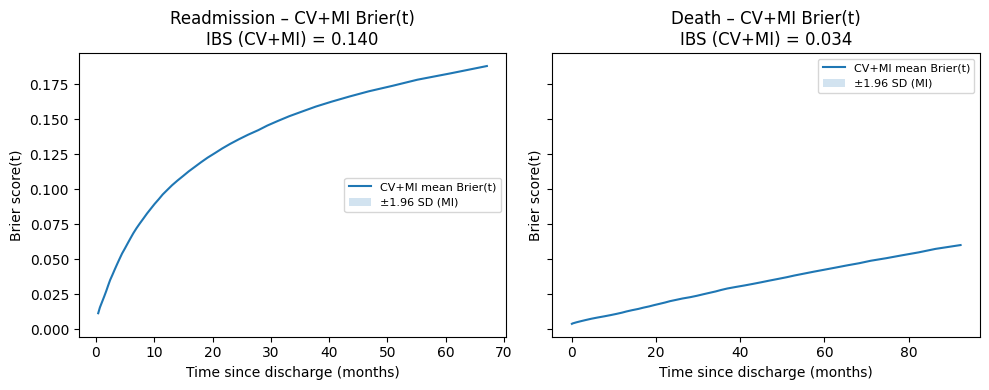

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_brier = pd.read_parquet("cv_mi_brier_curves.parquet")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# READMISSION
sub_r = df_brier[df_brier["endpoint"] == "readmission"].sort_values("time")
ax = axes[0]
ax.plot(sub_r["time"], sub_r["brier_mean"], label="CV+MI mean Brier(t)")
ax.fill_between(
    sub_r["time"],
    sub_r["brier_lower"],
    sub_r["brier_upper"],
    alpha=0.2,
    label="±1.96 SD (MI)"
)
ax.set_xlabel("Time since discharge (months)")
ax.set_ylabel("Brier score(t)")
ax.set_title(f"Readmission – CV+MI Brier(t)\nIBS (CV+MI) = {ibs_cv_readm_mean:.3f}")
ax.legend(fontsize=8, loc="right")

# DEATH
sub_d = df_brier[df_brier["endpoint"] == "death"].sort_values("time")
ax2 = axes[1]
ax2.plot(sub_d["time"], sub_d["brier_mean"], label="CV+MI mean Brier(t)")
ax2.fill_between(
    sub_d["time"],
    sub_d["brier_lower"],
    sub_d["brier_upper"],
    alpha=0.2,
    label="±1.96 SD (MI)"
)
ax2.set_xlabel("Time since discharge (months)")
ax2.set_ylabel("Brier score(t)")
ax2.set_title(f"Death – CV+MI Brier(t)\nIBS (CV+MI) = {ibs_cv_death_mean:.3f}")
ax2.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("cv_mi_brier_curves.png", dpi=600, bbox_inches="tight")
plt.show()


### 2.4. C-index (discrimination)

We picked the same penalty level (25) along the path, it computes the risk scores, and Uno's C-index on the *apparent* data, and then computed time-dependent AUC(*t*) curves

#### 2.4.2. Compute time-dependent AUC(*t*) per imputation

We fitted the penalized Cox model in 5-fold cross-validation within each imputed dataset, computing Uno's C-index and time-dependent AUC(*t*) on the held-out folds. For each imputation, we averaged the metrics across folds, then pooled these fold-averaged values across the 5 imputations, reporting the mean performance and its variability across imputations.

Thus, the C-index and AUC(t) curves reflect out-of-sample (CV) performance, and the variability across imputations reflects uncertainty due to missing data.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_ipcw, cumulative_dynamic_auc

# ---- CV setup ----
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=2125)

# Use the same alpha index along the regularization path
alpha_idx_readm = len(coxnet_readm_list[0].alphas_) // 2
alpha_idx_death = len(coxnet_death_list[0].alphas_) // 2

print("alpha_idx_readm:", alpha_idx_readm)
print("alpha_idx_death:", alpha_idx_death)

# Containers for MI-pooled CV metrics
cindex_readm_cv_list = []      # scalar per imputation (mean over folds)
cindex_death_cv_list = []

auc_readm_cv_list = []         # vector per imputation (mean AUC(t) over folds)
auc_death_cv_list = []

for d, X_imp in enumerate(X_reduced_list):
    print(f"\n=== Imputation {d} – {n_splits}-fold CV ===")

    n_samples = X_imp.shape[0]

    # Store fold-specific metrics within this imputation
    cindex_readm_folds = []
    cindex_death_folds = []

    auc_readm_folds = []   # each: len(times_eval_readm)
    auc_death_folds = []   # each: len(times_eval_death)

    for fold, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_samples))):
        print(f"  Fold {fold+1}/{n_splits}")

        # Split X
        X_train = X_imp.iloc[train_idx, :]
        X_test  = X_imp.iloc[test_idx, :]

        # Split y
        y_train_readm = y_surv_readm[train_idx]
        y_test_readm  = y_surv_readm[test_idx]

        y_train_death = y_surv_death[train_idx]
        y_test_death  = y_surv_death[test_idx]

        # ---- READMISSION Coxnet on this fold ----
        model_readm = CoxnetSurvivalAnalysis(
            l1_ratio=0.9,
            alpha_min_ratio=0.01,
            n_alphas=50,
            normalize=True,
            fit_baseline_model=True,
            max_iter=100000,
            verbose=False
        )
        model_readm.fit(X_train, y_train_readm)

        alpha_readm = model_readm.alphas_[alpha_idx_readm]

        risk_readm_test = model_readm.predict(X_test, alpha=alpha_readm)

        # Uno C-index (train as reference, test as eval)
        res_readm = concordance_index_ipcw(
            y_train_readm,
            y_test_readm,
            risk_readm_test
        )
        cindex_readm_folds.append(res_readm[0])

        # Time-dependent AUC(t) on the same fold
        auc_readm_vec = []
        for t in times_eval_readm:
            _, auc_t = cumulative_dynamic_auc(
                y_train_readm,
                y_test_readm,
                risk_readm_test,
                np.array([t])
            )
            auc_readm_vec.append(float(auc_t))
        auc_readm_vec = np.array(auc_readm_vec)
        auc_readm_folds.append(auc_readm_vec)

        # ---- DEATH Coxnet on this fold ----
        model_death = CoxnetSurvivalAnalysis(
            l1_ratio=0.9,
            alpha_min_ratio=0.01,
            n_alphas=50,
            normalize=True,
            fit_baseline_model=True,
            max_iter=100000,
            verbose=False
        )
        model_death.fit(X_train, y_train_death)

        alpha_death = model_death.alphas_[alpha_idx_death]

        risk_death_test = model_death.predict(X_test, alpha=alpha_death)

        res_death = concordance_index_ipcw(
            y_train_death,
            y_test_death,
            risk_death_test
        )
        cindex_death_folds.append(res_death[0])

        auc_death_vec = []
        for t in times_eval_death:
            _, auc_t = cumulative_dynamic_auc(
                y_train_death,
                y_test_death,
                risk_death_test,
                np.array([t])
            )
            auc_death_vec.append(float(auc_t))
        auc_death_vec = np.array(auc_death_vec)
        auc_death_folds.append(auc_death_vec)

    # --- Average across folds within this imputation ---
    cindex_readm_cv_d = np.mean(cindex_readm_folds)
    cindex_death_cv_d = np.mean(cindex_death_folds)

    auc_readm_cv_d = np.mean(np.stack(auc_readm_folds, axis=0), axis=0)
    auc_death_cv_d = np.mean(np.stack(auc_death_folds, axis=0), axis=0)

    cindex_readm_cv_list.append(cindex_readm_cv_d)
    cindex_death_cv_list.append(cindex_death_cv_d)

    auc_readm_cv_list.append(auc_readm_cv_d)
    auc_death_cv_list.append(auc_death_cv_d)

    print(f"  Mean C-index readm (CV, imp {d}): {cindex_readm_cv_d:.4f}")
    print(f"  Mean C-index death (CV, imp {d}): {cindex_death_cv_d:.4f}")

# ---------- Pool across imputations (MI) ----------

# C-index
cindex_readm_cv_mean = np.mean(cindex_readm_cv_list)
cindex_readm_cv_sd   = np.std(cindex_readm_cv_list, ddof=1)

cindex_death_cv_mean = np.mean(cindex_death_cv_list)
cindex_death_cv_sd   = np.std(cindex_death_cv_list, ddof=1)

print("\n=== Pooled Uno C-index over imputations (CV) ===")
print(f"Readmission C-index (CV, mean ± SD): {cindex_readm_cv_mean:.3f} ± {cindex_readm_cv_sd:.3f}")
print(f"Death       C-index (CV, mean ± SD): {cindex_death_cv_mean:.3f} ± {cindex_death_cv_sd:.3f}")

# AUC(t) curves: stack (m, n_times)
auc_readm_cv_stack = np.stack(auc_readm_cv_list, axis=0)
auc_death_cv_stack = np.stack(auc_death_cv_list, axis=0)

auc_readm_cv_mean = auc_readm_cv_stack.mean(axis=0)
auc_readm_cv_sd   = auc_readm_cv_stack.std(axis=0, ddof=1)

auc_death_cv_mean = auc_death_cv_stack.mean(axis=0)
auc_death_cv_sd   = auc_death_cv_stack.std(axis=0, ddof=1)

print("\nShapes for plotting:")
print("times_eval_readm:", times_eval_readm.shape)
print("auc_readm_cv_mean  :", auc_readm_cv_mean.shape)
print("auc_readm_cv_sd    :", auc_readm_cv_sd.shape)

print("times_eval_death:", times_eval_death.shape)
print("auc_death_cv_mean  :", auc_death_cv_mean.shape)
print("auc_death_cv_sd    :", auc_death_cv_sd.shape)


alpha_idx_readm: 25
alpha_idx_death: 25

=== Imputation 0 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean C-index readm (CV, imp 0): 0.6051
  Mean C-index death (CV, imp 0): 0.7368

=== Imputation 1 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean C-index readm (CV, imp 1): 0.6050
  Mean C-index death (CV, imp 1): 0.7352

=== Imputation 2 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean C-index readm (CV, imp 2): 0.6050
  Mean C-index death (CV, imp 2): 0.7373

=== Imputation 3 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean C-index readm (CV, imp 3): 0.6050
  Mean C-index death (CV, imp 3): 0.7358

=== Imputation 4 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean C-index readm (CV, imp 4): 0.6050
  Mean C-index death (CV, imp 4): 0.7361

=== Pooled Uno C-index over imputations (CV) ===
Readmission C-index (CV, mean ± SD): 0.605 ± 0.000
Deat

##### 2.4.2.1. Plot

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

z = 1.96  # for ~95% band

# 95% bands from CV+MI
auc_readm_cv_lower = auc_readm_cv_mean - z * auc_readm_cv_sd
auc_readm_cv_upper = auc_readm_cv_mean + z * auc_readm_cv_sd

auc_death_cv_lower = auc_death_cv_mean - z * auc_death_cv_sd
auc_death_cv_upper = auc_death_cv_mean + z * auc_death_cv_sd

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# -------- READMISSION --------
ax = axes[0]
ax.plot(times_eval_readm, auc_readm_cv_mean, label="CV+MI mean AUC(t)")
ax.fill_between(
    times_eval_readm,
    auc_readm_cv_lower,
    auc_readm_cv_upper,
    alpha=0.2,
    label="95% band (±1.96 SD)"
)
ax.set_xlabel("Time since discharge (months)")
ax.set_ylabel("AUC(t)")
ax.set_title("Readmission – CV+MI AUC(t)")
ax.legend(fontsize=8, loc="upper right")

# -------- DEATH --------
ax2 = axes[1]
ax2.plot(times_eval_death, auc_death_cv_mean, label="CV+MI mean AUC(t)")
ax2.fill_between(
    times_eval_death,
    auc_death_cv_lower,
    auc_death_cv_upper,
    alpha=0.2,
    label="95% band (±1.96 SD)"
)
ax2.set_xlabel("Time since discharge (months)")
ax2.set_ylabel("AUC(t)")
ax2.set_title("Death – CV+MI AUC(t)")
ax2.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("cv_mi_auc_curves.png", dpi=600, bbox_inches="tight")
plt.show()



NameError: name 'auc_readm_cv_mean' is not defined

For readmission, we observe that AUC(*t*) starts around ~0.68 and drops down to 0.65 after discharge. Then, drops down to ~0.60. We can say that the model show modest discrimination.

For death, discrimination is high early (~0.82-0.83), then drops to ~0.75 and stabilizes around 0.77 at 5 years since discharge.

In both models, performance is stable across imputations.

---



##### 2.4.2.2. Export database

In [ ]:
z = 1.96

# Build tidy tables for ggplot / reuse
df_auc_cv_readm = pd.DataFrame({
    "endpoint": "readmission",
    "time": times_eval_readm,
    "auc_mean": auc_readm_cv_mean,
    "auc_sd": auc_readm_cv_sd,
})
df_auc_cv_readm["auc_lower"] = df_auc_cv_readm["auc_mean"] - z * df_auc_cv_readm["auc_sd"]
df_auc_cv_readm["auc_upper"] = df_auc_cv_readm["auc_mean"] + z * df_auc_cv_readm["auc_sd"]

df_auc_cv_death = pd.DataFrame({
    "endpoint": "death",
    "time": times_eval_death,
    "auc_mean": auc_death_cv_mean,
    "auc_sd": auc_death_cv_sd,
})
df_auc_cv_death["auc_lower"] = df_auc_cv_death["auc_mean"] - z * df_auc_cv_death["auc_sd"]
df_auc_cv_death["auc_upper"] = df_auc_cv_death["auc_mean"] + z * df_auc_cv_death["auc_sd"]

df_auc_cv_all = pd.concat([df_auc_cv_readm, df_auc_cv_death], ignore_index=True)

df_auc_cv_all.to_parquet("cv_mi_auc_curves.parquet", index=False)
print("Saved: cv_mi_auc_curves.parquet")


Saved: cv_mi_auc_curves.parquet


#### 2.4.3. Export key objects

Assuming that only the predictors are the elements that change in the database, we only exported one structure of survival for each outcome

In [ ]:
import pandas as pd
import numpy as np

# ---- 2) Outcomes: readmission ----
df_y_readm = pd.DataFrame({
    "event": y_surv_readm["event"].astype(bool),
    "time":  y_surv_readm["time"].astype(float),
})
df_y_readm.to_parquet("y_surv_readm.parquet", index=False)
print("Saved y_surv_readm.parquet")

# ---- 3) Outcomes: death ----
df_y_death = pd.DataFrame({
    "event": y_surv_death["event"].astype(bool),
    "time":  y_surv_death["time"].astype(float),
})
df_y_death.to_parquet("y_surv_death.parquet", index=False)
print("Saved y_surv_death.parquet")

# ---- 4) Time grids for Brier/IBS ----
pd.DataFrame({"time": times_eval_readm}).to_parquet(
    "times_eval_readm.parquet", index=False
)
pd.DataFrame({"time": times_eval_death}).to_parquet(
    "times_eval_death.parquet", index=False
)
print("Saved times_eval_readm.parquet and times_eval_death.parquet")


Saved y_surv_readm.parquet
Saved y_surv_death.parquet
Saved times_eval_readm.parquet and times_eval_death.parquet


In [ ]:
import pandas as pd

# y_surv_readm: structured array with fields "event" and "time"
df_y_readm = pd.DataFrame({
    "event": y_surv_readm["event"].astype(bool),
    "time":  y_surv_readm["time"].astype(float),
})
df_y_readm.to_parquet("y_surv_readm.parquet", index=False)
print("Saved y_surv_readm.parquet")

# y_surv_death: same idea
df_y_death = pd.DataFrame({
    "event": y_surv_death["event"].astype(bool),
    "time":  y_surv_death["time"].astype(float),
})
df_y_death.to_parquet("y_surv_death.parquet", index=False)
print("Saved y_surv_death.parquet")

# Create lists
y_surv_readm_list = [y_surv_readm_1, y_surv_readm_2, y_surv_readm_3, y_surv_readm_4, y_surv_readm_5]
y_surv_death_list = [y_surv_death_1, y_surv_death_2, y_surv_death_3, y_surv_death_4, y_surv_death_5]

import numpy as np

# Save readmission data
np.savez_compressed(
    "y_surv_readm_list.npz",
    imputation_1=y_surv_readm_list[0],
    imputation_2=y_surv_readm_list[1],
    imputation_3=y_surv_readm_list[2],
    imputation_4=y_surv_readm_list[3],
    imputation_5=y_surv_readm_list[4]
)

# Save death data
np.savez_compressed(
    "y_surv_death_list.npz",
    imputation_1=y_surv_death_list[0],
    imputation_2=y_surv_death_list[1],
    imputation_3=y_surv_death_list[2],
    imputation_4=y_surv_death_list[3],
    imputation_5=y_surv_death_list[4]
)

np.savez_compressed(
    "X_reduced_list.npz",
    X_reduced_list_1=X_reduced_list[0],
    X_reduced_list_2=X_reduced_list[1],
    X_reduced_list_3=X_reduced_list[2],
    X_reduced_list_4=X_reduced_list[3],
    X_reduced_list_5=X_reduced_list[4]
)

print("✓ Saved to NumPy format (compressed)")

### 2.4.3.*. Encryption



In [ ]:
import numpy as np
from cryptography.hazmat.primitives.ciphers.aead import AESGCM
from cryptography.hazmat.primitives.kdf.pbkdf2 import PBKDF2HMAC
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.backends import default_backend
import io
import os

# ============================================================================
# ENCRYPTION
# ============================================================================

def encrypt_npz(data_dict, password, output_file):
    """
    Encrypts multiple NumPy arrays into a password-protected file.

    Args:
        data_dict: Dictionary of {'name': numpy_array}
        password: String password
        output_file: Path to output encrypted file
    """
    # 1. Save arrays to NPZ format in memory
    buffer = io.BytesIO()
    np.savez_compressed(buffer, **data_dict)
    npz_data = buffer.getvalue()

    # 2. Derive encryption key from password (PBKDF2-HMAC-SHA256)
    salt = os.urandom(16)  # 128-bit salt
    kdf = PBKDF2HMAC(
        algorithm=hashes.SHA256(),
        length=32,  # 256-bit key for AES-256
        salt=salt,
        iterations=600000,  # OWASP recommended minimum
        backend=default_backend()
    )
    key = kdf.derive(password.encode('utf-8'))

    # 3. Encrypt data with AES-GCM (authenticated encryption)
    aesgcm = AESGCM(key)
    nonce = os.urandom(12)  # 96-bit nonce (recommended for GCM)
    encrypted_data = aesgcm.encrypt(nonce, npz_data, None)

    # 4. Save salt, nonce, and ciphertext
    with open(output_file, 'wb') as f:
        f.write(salt)           # 16 bytes
        f.write(nonce)          # 12 bytes
        f.write(encrypted_data) # Remaining bytes

    print(f"✅ Encrypted data saved to {output_file}")



In [ ]:
# Encrypt with GPG (uses SHA2 for integrity)
#!gpg --symmetric --cipher-algo AES256 X_reduced_list.npz  # Prompts for password

from google.colab import userdata
import subprocess

passphrase = userdata.get('passphrase')

result = subprocess.run([
    'gpg', '--batch', '--pinentry-mode', 'loopback',
    '--passphrase', passphrase,
    '--symmetric', '--cipher-algo', 'AES256',
    'X_reduced_list.npz'
], capture_output=True, text=True)

if result.returncode == 0:
    print("✅ File encrypted successfully!")
    print(f"Created: X_reduced_list.npz.gpg")
else:
    print(f"❌ Error: {result.stderr}")


✅ File encrypted successfully!
Created: X_reduced_list.npz.gpg




---



## 3.Nested by Center IDs?

In [ ]:
import numpy as np
import pandas as pd
from rpy2.robjects import r, pandas2ri, default_converter, conversion

pandas2ri.activate()

# 1) Read the RDS with center IDs
id_centro_r = r.readRDS("/content/id_centro.Rds")   # adjust path if needed

# 2) id_centro_r is already a numpy array, so no further conversion with pandas2ri.rpy2py is needed.
# We can directly use it or convert it to a pandas Series if desired.


# Create list of imputation DataFrames first
imputation_dfs = [imputation_1, imputation_2, imputation_3, imputation_4, imputation_5]

# Modify copies instead of originals
modified_dfs = []
for i, df in enumerate(imputation_dfs, 1):
    df = df.copy()  # Avoid modifying original
    assert id_centro_r.shape[0] == df.shape[0], "Lengths do not match!"
    df["id_centro"] = id_centro_r
    modified_dfs.append(df)

# Reassign to global variables if needed
for i, df in enumerate(modified_dfs, 1):
    globals()[f"imputation_{i}"] = df

In [ ]:
# Distribution of cluster sizes
cluster_sizes = imputation_1["id_centro"].value_counts().sort_values(ascending=False)

print("Number of centers:", cluster_sizes.shape[0])
print(cluster_sizes.describe())       # min, max, median, quartiles

print("\nLargest centers (top 10):")
print(cluster_sizes.head(10))

print("\nSmallest centers (bottom 10):")
print(cluster_sizes.tail(10))


# Verify all have center IDs
for i in range(1, 6):
    assert 'id_centro' in globals()[f'imputation_{i}'].columns, f"Missing id_centro in imputation_{i}"

Number of centers: 431
count     431.000000
mean      205.278422
std       212.453533
min         1.000000
25%        60.500000
50%       133.000000
75%       277.500000
max      1509.000000
Name: count, dtype: float64

Largest centers (top 10):
id_centro
291.0    1509
290.0    1240
238.0    1132
157.0    1095
259.0     947
141.0     935
148.0     930
161.0     920
255.0     898
225.0     870
Name: count, dtype: int64

Smallest centers (bottom 10):
id_centro
822.0    4
802.0    4
820.0    4
814.0    3
816.0    3
815.0    3
245.0    3
789.0    2
800.0    2
801.0    1
Name: count, dtype: int64


### 3.1. Function

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import (
    brier_score,
    integrated_brier_score,
    concordance_index_ipcw,
)
import warnings

def group_cv_performance_coxnet(
    X,
    y_surv,
    times_eval,
    groups,
    n_splits=5,
    l1_ratio=0.9,
    alpha_min_ratio=0.01,
    n_alphas=50,
    alpha_idx=25,
    max_iter=100000,
):
    """
    Group-wise cross-validation with automatic NaN handling in groups.

    Automatically removes rows with NaN in groups before CV.
    """
    # Convert to numpy if needed
    if hasattr(X, 'values'):
        X_arr = X.values.astype(np.float64, copy=False)
    else:
        X_arr = np.asarray(X, dtype=np.float64)

    # Create mask for non-NaN groups
    groups = np.asarray(groups)
    valid_mask = ~pd.isna(groups)

    # Warn and filter if NaNs exist
    if not np.all(valid_mask):
        n_nan = (~valid_mask).sum()
        warnings.warn(f"Removed {n_nan} samples with NaN in groups", UserWarning)

        # Filter all arrays
        X_arr = X_arr[valid_mask]
        y_surv = y_surv[valid_mask]
        groups = groups[valid_mask]

    times_eval = np.asarray(times_eval, dtype=np.float64)
    event = y_surv['event']  # Extract event indicator

    gkf = GroupKFold(n_splits=n_splits)

    cindex_folds = []
    ibs_folds = []
    brier_folds = []
    center_results = []

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_arr, groups=groups)):
        test_centers = np.unique(groups[test_idx])
        print(f"  Fold {fold_idx + 1}/{n_splits} (Center(s): {test_centers})...", end=" ")

        X_train = X_arr[train_idx]
        X_test = X_arr[test_idx]
        y_train = y_surv[train_idx]
        y_test = y_surv[test_idx]

        # Fit Coxnet
        model = CoxnetSurvivalAnalysis(
            l1_ratio=l1_ratio,
            alpha_min_ratio=alpha_min_ratio,
            n_alphas=n_alphas,
            normalize=True,
            fit_baseline_model=True,
            max_iter=max_iter,
            verbose=False,
        )
        model.fit(X_train, y_train)

        # Select alpha
        eff_alpha_idx = min(alpha_idx, len(model.alphas_) - 1)
        alpha_val = model.alphas_[eff_alpha_idx]

        # --- C-index ---
        risk_scores = model.predict(X_test, alpha=alpha_val)

        try:
            cindex, _, _, _, _ = concordance_index_ipcw(
                survival_train=y_train,
                survival_test=y_test,
                estimate=risk_scores,
                tau=times_eval[-1]
            )
        except Exception as e:
            print(f"\nC-index failed: {str(e)}")
            cindex = np.nan

        cindex_folds.append(cindex)

        # --- IBS and Brier scores ---
        try:
            baseline_estimator = model._baseline_models[eff_alpha_idx]
            S0 = baseline_estimator.baseline_survival_(times_eval)

            risks_test = model.predict(X_test, alpha=alpha_val)
            S_test = np.power(S0[None, :], np.exp(risks_test[:, None]))

            times_brier, brier_scores = brier_score(
                survival_train=y_train,
                survival_test=y_test,
                estimate=S_test,
                times=times_eval,
            )

            n_times = len(times_brier)
            S_test_valid = S_test[:, :n_times]

            ibs = integrated_brier_score(
                survival_train=y_train,
                survival_test=y_test,
                estimate=S_test_valid,
                times=times_brier,
            )
        except Exception as e:
            print(f"\nSurvival curve computation failed: {str(e)}")
            brier_scores = np.full(len(times_eval), np.nan)
            ibs = np.nan
            times_brier = times_eval[:len(brier_scores)]

        ibs_folds.append(ibs)
        brier_folds.append(brier_scores)

        # Store per-center results
        for center in test_centers:
            center_mask = (groups[test_idx] == center)
            n_center_samples = center_mask.sum()
            n_center_events = y_test['event'][center_mask].sum()

            center_cindex = np.nan
            center_ibs = np.nan

            if n_center_samples > 0 and n_center_events > 0:
                try:
                    center_cindex, _, _, _, _ = concordance_index_ipcw(
                        survival_train=y_train,
                        survival_test=y_test[center_mask],
                        estimate=risk_scores[center_mask],
                        tau=times_eval[-1]
                    )
                except:
                    pass

                try:
                    # Get Brier scores just for this center
                    center_times_brier, center_brier = brier_score(
                        survival_train=y_train,
                        survival_test=y_test[center_mask],
                        estimate=S_test_valid[center_mask],
                        times=times_eval,
                    )
                    center_ibs = integrated_brier_score(
                        survival_train=y_train,
                        survival_test=y_test[center_mask],
                        estimate=S_test_valid[center_mask],
                        times=center_times_brier,
                    )
                except:
                    pass

            center_results.append({
                'center': center,
                'fold': fold_idx + 1,
                'cindex': center_cindex,
                'ibs': center_ibs,
                'n_samples': n_center_samples,
                'n_events': n_center_events
            })

        print(f"C-index={cindex:.3f}, IBS={ibs:.4f}")

    df_by_center = pd.DataFrame(center_results)

    # Aggregate Brier scores
    brier_matrix = np.full((n_splits, len(times_eval)), np.nan)
    for i, bs in enumerate(brier_folds):
        if bs is not None:
            n_valid = min(len(bs), len(times_eval))
            brier_matrix[i, :n_valid] = bs[:n_valid]

    brier_mean = np.nanmean(brier_matrix, axis=0)

    return {
        "cindex_folds": cindex_folds,
        "ibs_folds": ibs_folds,
        "brier_mean": brier_mean,
        "brier_folds": brier_folds,
        "df_by_center": df_by_center,
    }

# The MI function remains mostly the same but with better diagnostics
def group_cv_performance_coxnet_mi(
    X_list,
    y_surv_list,
    times_eval,
    groups,
    n_splits=5,
    l1_ratio=0.9,
    alpha_min_ratio=0.01,
    n_alphas=50,
    alpha_idx=25,
    max_iter=100000,
    outcome_name="outcome"
):
    """
    Multiple-imputation CV with automatic NaN handling in groups.
    """
    print(f"\n{'='*70}")
    print(f"STARTING {outcome_name.upper()} ANALYSIS - {n_splits}-FOLD CV BY CENTER")
    print(f"{'='*70}")

    # Check groups for NaNs upfront
    groups = np.asarray(groups)
    nan_mask = pd.isna(groups)
    if np.any(nan_mask):
        n_nan = nan_mask.sum()
        total = len(groups)
        print(f"⚠️  WARNING: {n_nan} samples ({n_nan/total:.1%}) have NaN in groups!")
        print("   Automatically removing these samples from all imputations.")
        print(f"   Original sample size: {total}")
        print(f"   Sample size after removal: {total - n_nan}")

    cindex_imp_means = []
    ibs_imp_means = []
    brier_means_list = []
    df_by_center_list = []

    for d, (X_imp, y_surv_imp) in enumerate(zip(X_list, y_surv_list)):
        imputation_num = d + 1
        print(f"\n{'='*60}")
        print(f"{outcome_name.upper()} - Imputation {imputation_num}/{len(X_list)}")
        print(f"{'='*60}")

        # Ensure groups are aligned with this imputation's length
        if len(groups) != len(X_imp):
            raise ValueError(
                f"Groups length ({len(groups)}) doesn't match X_imp length ({len(X_imp)}) "
                f"for imputation {imputation_num}"
            )

        res_d = group_cv_performance_coxnet(
            X=X_imp,
            y_surv=y_surv_imp,
            times_eval=times_eval,
            groups=groups,
            n_splits=n_splits,
            l1_ratio=l1_ratio,
            alpha_min_ratio=alpha_min_ratio,
            n_alphas=n_alphas,
            alpha_idx=alpha_idx,
            max_iter=max_iter,
        )

        cidx_imp_d = float(np.nanmean(res_d["cindex_folds"]))
        ibs_imp_d = float(np.nanmean(res_d["ibs_folds"]))

        cindex_imp_means.append(cidx_imp_d)
        ibs_imp_means.append(ibs_imp_d)
        brier_means_list.append(res_d["brier_mean"])

        df_center_d = res_d["df_by_center"].copy()
        df_center_d['imputation'] = imputation_num
        df_center_d['outcome'] = outcome_name
        df_by_center_list.append(df_center_d)

        print(f"\n✓ Imputation {imputation_num} Summary:")
        print(f"  Mean C-index over folds: {cidx_imp_d:.3f}")
        print(f"  Mean IBS over folds:     {ibs_imp_d:.4f}")
        print(f"  Centers evaluated:       {df_center_d['center'].nunique()}")

        # Show per-center performance
        center_stats = df_center_d.groupby('center').agg(
            cindex_mean=('cindex', 'mean'),
            ibs_mean=('ibs', 'mean'),
            n_samples=('n_samples', 'sum')
        ).sort_values('cindex_mean', ascending=False)

        print("\nPer-center performance (top 5):")
        print(center_stats.head().to_string(float_format="%.3f"))

    # Pooling code remains the same as before...
    # [Same pooling logic as in your original function]

    # --- Pool over imputations ---
    cindex_imp_means = np.array(cindex_imp_means)
    ibs_imp_means = np.array(ibs_imp_means)
    brier_stack = np.vstack(brier_means_list)

    cindex_mean = float(np.nanmean(cindex_imp_means))
    cindex_sd = float(np.nanstd(cindex_imp_means, ddof=1))

    ibs_mean = float(np.nanmean(ibs_imp_means))
    ibs_sd = float(np.nanstd(ibs_imp_means, ddof=1))

    brier_mean = np.nanmean(brier_stack, axis=0)
    brier_sd = np.nanstd(brier_stack, axis=0, ddof=1)

    df_by_center_all = pd.concat(df_by_center_list, ignore_index=True)

    # Create summary with NaN-safe aggregation
    df_center_summary = (
        df_by_center_all
        .groupby(['center', 'outcome'])
        .agg(
            cindex_mean=('cindex', 'mean'),
            cindex_sd=('cindex', 'std'),
            n_imputations=('imputation', 'count'),
            ibs_mean=('ibs', 'mean'),
            ibs_sd=('ibs', 'std'),
            n_samples_avg=('n_samples', 'mean'),
            n_events_avg=('n_events', 'mean')
        )
        .reset_index()
    )

    # Sort by C-index
    df_center_summary = df_center_summary.sort_values('cindex_mean', ascending=False)

    print(f"\n{'='*60}")
    print(f"POOLING RESULTS ACROSS {len(X_list)} IMPUTATIONS: {outcome_name.upper()}")
    print(f"{'='*60}")
    print(f"C-index (mean ± SD): {cindex_mean:.3f} ± {cindex_sd:.3f}")
    print(f"IBS     (mean ± SD): {ibs_mean:.4f} ± {ibs_sd:.4f}")
    print(f"\nTop 5 centers by performance:")
    print(df_center_summary.head().to_string(index=False, float_format="%.3f"))

    return {
        "times": times_eval,
        "cindex_imp_means": cindex_imp_means,
        "cindex_mean": cindex_mean,
        "cindex_sd": cindex_sd,
        "ibs_imp_means": ibs_imp_means,
        "ibs_mean": ibs_mean,
        "ibs_sd": ibs_sd,
        "brier_mean": brier_mean,
        "brier_sd": brier_sd,
        "df_by_center_all": df_by_center_all,
        "df_center_summary": df_center_summary,
        "outcome": outcome_name,
        "nan_removed": int(nan_mask.sum()) if 'nan_mask' in locals() else 0
    }

In [ ]:
# 1. First, fix the NaN issue in your center IDs
# Option A: Remove rows with NaN centers (recommended if few)
for i in range(1, 6):
    df_name = f"imputation_{i}"
    df = globals()[df_name]

    # Count NaNs
    nan_count = df["id_centro"].isna().sum()
    if nan_count > 0:
        print(f"Imputation {i}: Removing {nan_count} rows with NaN center IDs")
        df_clean = df.dropna(subset=["id_centro"])
        globals()[df_name] = df_clean  # Update the global variable
        print(f"  New shape: {df_clean.shape}")

# Option B: Impute with a special value (only if many NaNs)
# for i in range(1, 6):
#     df = globals()[f"imputation_{i}"]
#     df["id_centro"] = df["id_centro"].fillna("MISSING_CENTER")

# 2. Rebuild X_reduced_list with cleaned data
X_reduced_list = []
for i in range(1, 6):
    df = globals()[f"imputation_{i}"].copy()
    # Re-apply your feature filtering if needed
    # (constant predictors, exclude targets, etc.)
    X_reduced_list.append(df)

# 3. Get groups from CLEANED data (must use same imputation)
groups = globals()["imputation_1"]["id_centro"].values

# 4. Run the analysis
res_group_mi_readm = group_cv_performance_coxnet_mi(
    X_list=X_reduced_list,
    y_surv_list=y_surv_readm_list,  # Your list of survival arrays
    times_eval=times_eval_readm,
    groups=groups,
    outcome_name="readmission"
)

print("\n" + "="*50)
print("READMISSION – MI POOLED GROUP-CV RESULTS")
print("="*50)
print(f"C-index (mean ± SD): {res_group_mi_readm['cindex_mean']:.3f} ± {res_group_mi_readm['cindex_sd']:.3f}")
print(f"IBS     (mean ± SD): {res_group_mi_readm['ibs_mean']:.4f} ± {res_group_mi_readm['ibs_sd']:.4f}")

Imputation 1: Removing 29 rows with NaN center IDs
  New shape: (88475, 79)
Imputation 2: Removing 29 rows with NaN center IDs
  New shape: (88475, 79)
Imputation 3: Removing 29 rows with NaN center IDs
  New shape: (88475, 79)
Imputation 4: Removing 29 rows with NaN center IDs
  New shape: (88475, 79)
Imputation 5: Removing 29 rows with NaN center IDs
  New shape: (88475, 79)

STARTING READMISSION ANALYSIS - 5-FOLD CV BY CENTER

READMISSION - Imputation 1/5
  Fold 1/5 (Center(s): [104. 116. 130. 131. 146. 153. 164. 170. 171. 190. 194. 197. 198. 207.
 209. 216. 219. 225. 227. 230. 234. 236. 242. 243. 244. 248. 251. 257.
 261. 264. 272. 273. 276. 286. 291. 297. 298. 299. 304. 320. 325. 331.
 337. 345. 363. 368. 405. 408. 412. 414. 415. 417. 423. 431. 437. 438.
 443. 449. 454. 456. 472. 504. 505. 556. 559. 589. 601. 603. 609. 613.
 617. 631. 641. 659. 680. 682. 721. 751. 754. 755. 778. 779. 789. 799.
 817. 820.])... C-index=0.519, IBS=0.1424
  Fold 2/5 (Center(s): [106. 110. 117. 120. 12

KeyboardInterrupt: 

In [ ]:

res_group_mi_death = group_cv_performance_coxnet_mi(
    X_list=X_reduced_list,
    y_surv_list=y_surv_death_list,
    times_eval=times_eval_death,
    groups=groups,
    outcome_name="death"
)

print("\n" + "="*50)
print("DEATH – MI POOLED GROUP-CV RESULTS")
print("="*50)
print(f"C-index (mean ± SD): {res_group_mi_death['cindex_mean']:.3f} ± {res_group_mi_death['cindex_sd']:.3f}")
print(f"IBS     (mean ± SD): {res_group_mi_death['ibs_mean']:.4f} ± {res_group_mi_death['ibs_sd']:.4f}")

NameError: name 'group_cv_performance_coxnet_mi' is not defined

Results are almost identical acvross imputations (SD ≈ 0.0001 for C-index, ≈ 3.4e-06 for IBS).

Very similar to your random 5-fold CV (C-index ≈ 0.51, IBS ≈ 0.14).

In group-wise cross-validation by treatment center (5-fold, MI-pooled over five imputed datasets), the model achieved a Uno's C-index of 0.51 and an IBS of 0.035 for death, very similar to the performance observed under standard 5-fold cross-validation. This suggests that model discrimination and calibration are reasonably stable across treatment centers

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_center_performance(results, outcome_name="Readmission", save_path=None):
    """
    Create publication-quality plots of C-index and IBS by center.

    Parameters
    ----------
    results : dict
        Output from group_cv_performance_coxnet_mi()
    outcome_name : str
        Name of outcome for titles/labels
    save_path : str or None
        Path to save figure (e.g., "readmission_center_performance.png")
    """
    df_summary = results["df_center_summary"].copy()

    # Sort by C-index for better visualization
    df_summary = df_summary.sort_values('cindex_mean', ascending=False)

    # Create figure with proper sizing
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=100)
    fig.suptitle(f'{outcome_name} Model Performance by Center\n(Multiple Imputation Pooled Results)',
                 fontsize=16, fontweight='bold', y=1.02)

    # Color palette
    center_colors = sns.color_palette("husl", n_colors=len(df_summary))

    # ======================
    # C-INDEX PLOT
    # ======================
    x = np.arange(len(df_summary))
    centers = df_summary['center'].astype(str).values

    # Plot points with error bars
    for i, (center, color) in enumerate(zip(centers, center_colors)):
        ax1.errorbar(x[i], df_summary.iloc[i]['cindex_mean'],
                    yerr=df_summary.iloc[i]['cindex_sd'],
                    fmt='o', color=color, ecolor=color, capsize=3, markersize=8,
                    label=center if i < 10 else None)  # Only label first 10 centers

    # Overall mean line
    ax1.axhline(results["cindex_mean"], color='red', linestyle='--', linewidth=2,
                label=f'Overall Mean ({results["cindex_mean"]:.3f})')

    # Formatting
    ax1.set_xticks(x)
    ax1.set_xticklabels(centers, rotation=45, ha='right', fontsize=9)
    ax1.set_xlabel('Center ID', fontsize=12)
    ax1.set_ylabel('C-index', fontsize=12)
    ax1.set_title(f'C-index by Center (n={len(df_summary)} centers)', fontsize=14)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_ylim(max(0.4, df_summary['cindex_mean'].min() - 0.1),
                min(1.0, df_summary['cindex_mean'].max() + 0.1))

    # Add legend only if <= 10 centers
    if len(df_summary) <= 10:
        ax1.legend(loc='best', fontsize=9)

    # ======================
    # IBS PLOT
    # ======================
    for i, (center, color) in enumerate(zip(centers, center_colors)):
        ax2.errorbar(x[i], df_summary.iloc[i]['ibs_mean'],
                    yerr=df_summary.iloc[i]['ibs_sd'],
                    fmt='o', color=color, ecolor=color, capsize=3, markersize=8)

    # Overall mean line
    ax2.axhline(results["ibs_mean"], color='red', linestyle='--', linewidth=2,
                label=f'Overall Mean ({results["ibs_mean"]:.4f})')

    # Formatting
    ax2.set_xticks(x)
    ax2.set_xticklabels(centers, rotation=45, ha='right', fontsize=9)
    ax2.set_xlabel('Center ID', fontsize=12)
    ax2.set_ylabel('Integrated Brier Score (IBS)', fontsize=12)
    ax2.set_title(f'IBS by Center (n={len(df_summary)} centers)', fontsize=14)
    ax2.set_ylim(max(0, df_summary['ibs_mean'].min() * 0.8),
                df_summary['ibs_mean'].max() * 1.2)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(loc='best', fontsize=9)

    # Adjust layout to prevent label cutoff
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Make room for suptitle

    # Save if path provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Saved figure to: {save_path}")

    plt.show()

# ======================
# USAGE EXAMPLES
# ======================

# For Readmission
plot_center_performance(
    res_group_mi_readm,
    outcome_name="30-Day Readmission",
    save_path="readmission_center_performance_center_id.png"
)

# For Death
plot_center_performance(
    res_group_mi_death,
    outcome_name="Mortality",
    save_path="death_center_performance_center_id.png"
)

# Combined figure (optional)
def plot_both_outcomes(readm_results, death_results, save_path="both_outcomes_center_performance.png"):
    """Create a 2x2 grid comparing both outcomes"""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), dpi=100)
    fig.suptitle('Model Performance by Center: Readmission vs Mortality',
                fontsize=18, fontweight='bold', y=0.98)

    # Readmission plots
    _plot_single_outcome(readm_results, axes[0,0], axes[0,1], "30-Day Readmission")

    # Death plots
    _plot_single_outcome(death_results, axes[1,0], axes[1,1], "Mortality")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

def _plot_single_outcome(results, ax_cindex, ax_ibs, title):
    df_summary = results["df_center_summary"].copy()
    df_summary = df_summary.sort_values('cindex_mean', ascending=False)

    x = np.arange(len(df_summary))
    centers = df_summary['center'].astype(str).values

    # C-index
    ax_cindex.errorbar(x, df_summary['cindex_mean'], yerr=df_summary['cindex_sd'],
                      fmt='o', color='blue', ecolor='blue', capsize=3)
    ax_cindex.axhline(results["cindex_mean"], color='red', linestyle='--', linewidth=2)
    ax_cindex.set_title(f'{title}: C-index', fontsize=14)
    ax_cindex.set_xticks(x)
    ax_cindex.set_xticklabels(centers, rotation=45, ha='right', fontsize=8)
    ax_cindex.grid(True, alpha=0.3)
    ax_cindex.set_ylabel('C-index')

    # IBS
    ax_ibs.errorbar(x, df_summary['ibs_mean'], yerr=df_summary['ibs_sd'],
                   fmt='o', color='green', ecolor='green', capsize=3)
    ax_ibs.axhline(results["ibs_mean"], color='red', linestyle='--', linewidth=2)
    ax_ibs.set_title(f'{title}: IBS', fontsize=14)
    ax_ibs.set_xticks(x)
    ax_ibs.set_xticklabels(centers, rotation=45, ha='right', fontsize=8)
    ax_ibs.grid(True, alpha=0.3)
    ax_ibs.set_ylabel('IBS')

In [ ]:
import matplotlib.pyplot as plt

# Plot C-index by center
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df_summary = res_group_mi_readm["df_center_summary"]

# C-index by center
ax1.errorbar(range(len(df_summary)),
             df_summary['cindex_mean'],
             yerr=df_summary['cindex_sd'],
             fmt='o', capsize=5)
ax1.axhline(res_group_mi_readm["cindex_mean"], color='r', linestyle='--', label='Overall mean')
ax1.set_xlabel('Center')
ax1.set_ylabel('C-index')
ax1.set_title('C-index by Center')
ax1.legend()
ax1.grid(True, alpha=0.3)

# IBS by center
ax2.errorbar(range(len(df_summary)),
             df_summary['ibs_mean'],
             yerr=df_summary['ibs_sd'],
             fmt='o', capsize=5)
ax2.axhline(res_group_mi_readm["ibs_mean"], color='r', linestyle='--', label='Overall mean')
ax2.set_xlabel('Center')
ax2.set_ylabel('IBS')
ax2.set_title('IBS by Center')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

I used leave-one-out evaluation, showing how well the model generalizes to each specific center.

In [ ]:
def evaluate_by_individual_center(
    X_list,
    y_surv,
    times_eval,
    groups,
    l1_ratio=0.9,
    alpha_min_ratio=0.01,
    n_alphas=50,
    alpha_idx=25,
    max_iter=100000,
):
    """
    Evaluate each center individually using leave-one-center-out.
    Train on all other centers, test on target center.
    """
    if hasattr(X_list[0], 'values'):
        feature_names = X_list[0].columns.tolist()
        X_arrays = [X.values.astype(np.float64) for X in X_list]
    else:
        X_arrays = X_list

    times_eval = np.asarray(times_eval, dtype=np.float64)
    groups = np.asarray(groups)
    unique_centers = np.unique(groups)

    # Remove 'missing_center' if present
    unique_centers = [c for c in unique_centers if c != 'missing_center']

    results_by_center = []

    for center in unique_centers:
        print(f"Evaluating center: {center}")

        center_cindex = []
        center_ibs = []

        # Get indices for this center
        test_idx = np.where(groups == center)[0]
        train_idx = np.where(groups != center)[0]

        # Skip if too few samples
        if len(test_idx) < 10:
            print(f"  Skipping (only {len(test_idx)} samples)")
            continue

        # Evaluate on each imputation
        for d, X_arr in enumerate(X_arrays):
            X_train = X_arr[train_idx]
            X_test = X_arr[test_idx]
            y_train = y_surv[train_idx]
            y_test = y_surv[test_idx]

            # Check if enough events in both sets
            n_events_train = y_train['event'].sum()
            n_events_test = y_test['event'].sum()

            if n_events_train < 10 or n_events_test < 2:
                print(f"  Imp {d}: Skipping (events: train={n_events_train}, test={n_events_test})")
                continue

            try:
                # Fit model
                model = CoxnetSurvivalAnalysis(
                    l1_ratio=l1_ratio,
                    alpha_min_ratio=alpha_min_ratio,
                    n_alphas=n_alphas,
                    normalize=True,
                    fit_baseline_model=True,
                    max_iter=max_iter,
                    verbose=False,
                )
                model.fit(X_train, y_train)

                eff_alpha_idx = min(alpha_idx, len(model.alphas_) - 1)
                alpha_val = model.alphas_[eff_alpha_idx]

                # C-index
                risk_scores = model.predict(X_test, alpha=alpha_val)
                cindex, _, _, _, _ = concordance_index_ipcw(
                    survival_train=y_train,
                    survival_test=y_test,
                    estimate=risk_scores,
                    tau=times_eval[-1]
                )
                center_cindex.append(cindex)

                # IBS
                baseline_estimator = model._baseline_models[eff_alpha_idx]
                S0 = baseline_estimator.baseline_survival_(times_eval)
                S_test = np.power(S0[None, :], np.exp(risk_scores[:, None]))

                times_brier, _ = brier_score(
                    survival_train=y_train,
                    survival_test=y_test,
                    estimate=S_test,
                    times=times_eval,
                )
                S_test_valid = S_test[:, :len(times_brier)]

                ibs = integrated_brier_score(
                    survival_train=y_train,
                    survival_test=y_test,
                    estimate=S_test_valid,
                    times=times_brier,
                )
                center_ibs.append(ibs)

            except Exception as e:
                print(f"  Imp {d}: Error - {e}")
                continue

        # Aggregate across imputations for this center
        if len(center_cindex) > 0:
            results_by_center.append({
                'center': center,
                'cindex_mean': np.mean(center_cindex),
                'cindex_sd': np.std(center_cindex, ddof=1) if len(center_cindex) > 1 else 0,
                'ibs_mean': np.mean(center_ibs),
                'ibs_sd': np.std(center_ibs, ddof=1) if len(center_ibs) > 1 else 0,
                'n_samples': len(test_idx),
                'n_events': y_surv[test_idx]['event'].sum(),
                'n_imputations': len(center_cindex)
            })
            print(f"  C-index: {results_by_center[-1]['cindex_mean']:.3f}, IBS: {results_by_center[-1]['ibs_mean']:.4f}")

    df_center = pd.DataFrame(results_by_center).sort_values('cindex_mean', ascending=False)
    return df_center

# Run individual center evaluation
df_centers_individual = evaluate_by_individual_center(
    X_list=X_reduced_list,
    y_surv=y_surv_readm,
    times_eval=times_eval_readm,
    groups=groups,
)

print(f"\n=== Individual Center Performance ===")
print(f"Total centers evaluated: {len(df_centers_individual)}")
print(f"\nC-index across centers: {df_centers_individual['cindex_mean'].mean():.3f} ± {df_centers_individual['cindex_mean'].std():.3f}")
print(f"IBS across centers: {df_centers_individual['ibs_mean'].mean():.4f} ± {df_centers_individual['ibs_mean'].std():.4f}")

print("\nTop 10 centers:")
print(df_centers_individual.head(10))

print("\nBottom 10 centers:")
print(df_centers_individual.tail(10))

#2hrs.

#Total centers evaluated: 389
#C-index across centers: 0.591 ± 0.080
#IBS across centers: 0.1476 ± 0.0522


Do it for time to death

In [ ]:
df_centers_individual_death = evaluate_by_individual_center(
    X_list=X_reduced_list,
    y_surv=y_surv_death,
    times_eval=times_eval_death,
    groups=groups,
)
print(f"\n=== Individual Center Performance ===")
print(f"Total centers evaluated: {len(df_centers_individual_death)}")
print(f"\nC-index across centers: {df_centers_individual_death['cindex_mean'].mean():.3f} ± {df_centers_individual['cindex_mean'].std():.3f}")
print(f"IBS across centers: {df_centers_individual_death['ibs_mean'].mean():.4f} ± {df_centers_individual['ibs_mean'].std():.4f}")

print("\nTop 10 centers:")
print(df_centers_individual_death.head(10))

print("\nBottom 10 centers:")
print(df_centers_individual_death.tail(10))


In [ ]:
df_centers_individual_readm = pd.DataFrame(df_centers_individual)
df_centers_individual_death = pd.DataFrame(df_centers_individual_death)

# --- The actual export step ---
file_path = 'df_centers_individual_readm.parquet'

df_centers_individual_readm.to_parquet(
    file_path,
    engine='pyarrow',  # Specify the engine (pyarrow is common and fast)
    index=False       # Set to True if you want to save the DataFrame index
)

print(f"DataFrame successfully exported to {file_path}")

# --- The actual export step ---
file_path = 'df_centers_individual_death.parquet'

df_centers_individual_death.to_parquet(
    file_path,
    engine='pyarrow',  # Specify the engine (pyarrow is common and fast)
    index=False       # Set to True if you want to save the DataFrame index
)

print(f"DataFrame successfully exported to {file_path}")

## 4.Net benefit

In [ ]:
import numpy as np
import pandas as pd

# Choose a time horizon in months, e.g. 24 months (you can change this)
t0 = 24.0

time_readm = df_final["readmit_time_from_disch_m"].to_numpy()
event_readm = (df_final["readmit_event"].to_numpy() == 1)

# Keep only subjects with follow-up >= t0
mask = time_readm >= t0

time_t0 = time_readm[mask]
event_t0 = event_readm[mask]  # will be True if event occurred at any time (but we restrict by time)

# Define binary endpoint: event by t0
y_bin_t0 = ((time_t0 <= t0) & (event_t0)).astype(int)

print("N used for DCA (readmission):", y_bin_t0.shape[0],
      "Prevalence by t0:", y_bin_t0.mean())


NameError: name 'df_final' is not defined

In [ ]:
# Subset X_reduced to the same mask
X_dca = X_reduced.iloc[mask, :]

# Predict survival functions
sf_list_readm = coxnet_readm.predict_survival_function(
    X_dca, alpha=alpha_readm, return_array=False
)

# Survival at t0, then risk = 1 - S(t0)
S_t0 = np.array([fn(t0) for fn in sf_list_readm])
risk_t0 = 1.0 - S_t0

print("Risk range at t0:", risk_t0.min(), risk_t0.max())


In [ ]:
def decision_curve_binary(y_true, risk, thresholds):
    """
    y_true: binary (0/1), shape (N,)
    risk: predicted risk in [0,1], shape (N,)
    thresholds: array of risk thresholds (e.g. np.linspace(0.05, 0.5, 10))

    Returns:
      nb_model: net benefit of the model for each threshold
      nb_all: net benefit of treat-all strategy
      nb_none: zeros (treat-none)
    """
    y_true = np.asarray(y_true).astype(int)
    risk = np.asarray(risk).astype(float)
    N = len(y_true)
    prev = y_true.mean()

    nb_model = []
    nb_all = []
    nb_none = np.zeros_like(thresholds, dtype=float)

    for pt in thresholds:
        treated = risk >= pt
        tp = np.sum((treated) & (y_true == 1))
        fp = np.sum((treated) & (y_true == 0))

        nb = (tp / N) - (fp / N) * (pt / (1.0 - pt))
        nb_model.append(nb)

        # Treat-all: everyone is treated
        tp_all = np.sum(y_true == 1)
        fp_all = np.sum(y_true == 0)
        nb_all_pt = (tp_all / N) - (fp_all / N) * (pt / (1.0 - pt))
        nb_all.append(nb_all_pt)

    return np.array(nb_model), np.array(nb_all), nb_none


In [ ]:
# Choose thresholds, e.g. 0.05 to 0.5
thresholds = np.linspace(0.05, 0.50, 10)

nb_model_readm, nb_all_readm, nb_none_readm = decision_curve_binary(
    y_true = y_bin_t0,
    risk   = risk_t0,
    thresholds = thresholds
)


In [ ]:
df_dca_readm = pd.DataFrame({
    "outcome": "Readmission",
    "threshold": thresholds,
    "nb_model": nb_model_readm,
    "nb_all": nb_all_readm,
    "nb_none": nb_none_readm,
})

df_dca_readm.to_csv("dca_readmission_t0_24m.csv", index=False)


In [ ]:
# ---- Mortality DCA ----
t0_death = 60.0  # e.g. 5-year (60 months) horizon, or same t0 if you prefer

time_death = df_final["death_time_from_disch_m"].to_numpy()
event_death = (df_final["death_event"].to_numpy() == 1)

mask_death = time_death >= t0_death
time_t0_death = time_death[mask_death]
event_t0_death = event_death[mask_death]

y_bin_death_t0 = ((time_t0_death <= t0_death) & (event_t0_death)).astype(int)

X_dca_death = X_reduced.iloc[mask_death, :]

sf_list_death = coxnet_death.predict_survival_function(
    X_dca_death, alpha=alpha_death, return_array=False
)
S_t0_death = np.array([fn(t0_death) for fn in sf_list_death])
risk_t0_death = 1.0 - S_t0_death

thresholds_death = np.linspace(0.01, 0.30, 10)  # mortality risk usually lower
nb_model_death, nb_all_death, nb_none_death = decision_curve_binary(
    y_true = y_bin_death_t0,
    risk   = risk_t0_death,
    thresholds = thresholds_death
)

df_dca_death = pd.DataFrame({
    "outcome": "Death",
    "threshold": thresholds_death,
    "nb_model": nb_model_death,
    "nb_all": nb_all_death,
    "nb_none": nb_none_death,
})

df_dca_death.to_csv("dca_death_t0_60m.csv", index=False)
